# Week 5 Lab — Classic ML II: Tree & Ensemble

## 실습 목표
1. **Decision Tree**가 데이터를 어떻게 분할하는지 직접 확인한다.
2. 깊이 제한이 없는 Tree와 제어된 Tree를 비교해 **과적합**을 체감한다.
3. **Graphviz / plot_tree** 기반으로 Tree 구조를 시각화한다.
4. **Random Forest**를 학습하고 단일 Tree와 성능 차이를 비교한다.
5. **Feature Importance**를 추출하고 해석 시 주의점을 정리한다.

---

## 오늘 실습 데이터
- 본 실습은 **Scikit-learn Wine** 데이터셋을 사용합니다.
- 이유:
  - 모든 feature가 수치형이라 Tree/Forest 실습에 집중하기 좋음
  - 클래스가 3개여서 분류 성능 비교가 단순 binary보다 풍부함
  - feature 수가 적당해서 시각화와 중요도 해석이 쉬움

> 오늘 핵심은 **"Tree를 학습시킨다"** 가 아니라  
> **"단일 Tree의 불안정성과 Ensemble의 안정성을 비교한다"** 입니다.


> **🗣️ [발표자 스크립트]**  
> "이번 실습은 5주차 이론에서 배운 내용을 코드로 닫는 시간입니다.  
> 먼저 Decision Tree가 얼마나 직관적인지 보고, 동시에 얼마나 쉽게 과적합되는지도 직접 확인하겠습니다.  
> 그 다음 여러 Tree를 모은 Random Forest가 왜 더 안정적인 baseline이 되는지 비교해 보겠습니다."

## 실습 전 준비
- Python 3.10+
- Jupyter Notebook 또는 Colab
- `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`
- Graphviz는 **선택 사항**입니다.
  - 설치되어 있으면 더 깔끔한 Tree 시각화가 가능
  - 설치되어 있지 않아도 `plot_tree`로 실습 진행 가능


In [ ]:
# 필요 패키지 설치 (최초 1회만)
# 로컬 uv 환경 예시
# !uv add pandas numpy matplotlib seaborn scikit-learn graphviz

# Colab / 일반 Jupyter 환경 예시
# !pip install pandas numpy matplotlib seaborn scikit-learn graphviz

# Graphviz 시스템 패키지가 없으면 아래 Graphviz 렌더링 셀은 건너뛰고
# plot_tree 시각화 셀만 사용해도 됩니다.


Resolved 250 packages in 680ms                                       
⠙ jupyter==1.1.1                                                                Uninstalled 8 packages in 1.33s
Installed 32 packages in 271ms                              
 - charset-normalizer==3.4.6
 + charset-normalizer==3.4.5
 + dacite==1.9.2
 + filetype==1.2.0
 - fonttools==4.62.1
 + fonttools==4.61.1
 + graphviz==0.21
 + imagehash==4.3.2
 + importlib-resources==6.5.2
 - kiwisolver==1.5.0
 + kiwisolver==1.4.9
 + llvmlite==0.45.1
 - matplotlib==3.10.8
 + matplotlib==3.10.0
 + minify-html==0.18.1
 + missingno==0.5.2
 + multimethod==1.12
 + numba==0.62.1
 - numpy==2.4.3
 + numpy==2.3.5
 - pandas==3.0.1
 + pandas==2.3.3
 + patsy==1.0.2
 + phik==0.12.5
 + puremagic==2.0.0
 + pytz==2026.1.post1
 + pywavelets==1.9.0
 - scipy==1.17.1
 + scipy==1.16.3
 + seaborn==0.13.2
 - setuptools==82.0.1
 + setuptools==82.0.0
 + statsmodels==0.14.6
 + sweetviz==2.3.1
 + typeguard==4.5.1
 + ucimlrepo==0.0.7
 + visions==0.8.1
 + wheel

## 1. 라이브러리 불러오기

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 2. 데이터셋 로드 및 기본 확인

In [5]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()

display(df.head())
print("shape:", df.shape)
print("target classes:", wine.target_names)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


shape: (178, 14)
target classes: ['class_0' 'class_1' 'class_2']


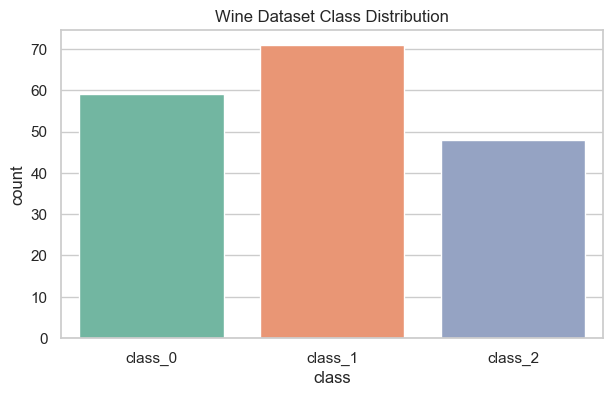

,count
target,
class_0,59
class_1,71
class_2,48


In [6]:
target_map = {i: name for i, name in enumerate(wine.target_names)}
class_counts = df["target"].map(target_map).value_counts().sort_index()

plt.figure(figsize=(7, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="Set2")
plt.title("Wine Dataset Class Distribution")
plt.xlabel("class")
plt.ylabel("count")
plt.show()

class_counts.to_frame("count")


## 3. Train / Test Split

- Tree 계열도 반드시 **학습 데이터와 평가 데이터**를 분리해야 합니다.
- 특히 이번 실습은 **과적합 비교**가 중요하므로 train/test 성능을 함께 봅니다.


In [7]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


X_train: (142, 13)
X_test : (36, 13)


## 4. 평가 함수 정의

In [8]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        "model": model_name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "train_f1_macro": f1_score(y_train, train_pred, average="macro"),
        "test_f1_macro": f1_score(y_test, test_pred, average="macro"),
    }


## 5. Baseline 1 — 깊이 제한이 없는 Decision Tree

- 먼저 **제한 없는 Tree**를 학습합니다.
- train 성능이 지나치게 높고 test 성능이 떨어지면 과적합 신호로 볼 수 있습니다.


In [9]:
tree_full = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree_full.fit(X_train, y_train)

result_tree_full = evaluate_classifier(
    tree_full, X_train, X_test, y_train, y_test, "DecisionTree (full depth)"
)
pd.DataFrame([result_tree_full])


,model,train_accuracy,test_accuracy,train_f1_macro,test_f1_macro
0,DecisionTree (full depth),1.0,0.944444,1.0,0.945741


## 6. Baseline 2 — 깊이를 제한한 Decision Tree

- `max_depth=3`으로 제어된 Tree를 학습합니다.
- 의도는 **해석 가능한 구조**와 **일반화 성능**의 균형을 보는 것입니다.


In [10]:
tree_controlled = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
tree_controlled.fit(X_train, y_train)

result_tree_controlled = evaluate_classifier(
    tree_controlled, X_train, X_test, y_train, y_test, "DecisionTree (max_depth=3)"
)
pd.DataFrame([result_tree_controlled])


,model,train_accuracy,test_accuracy,train_f1_macro,test_f1_macro
0,DecisionTree (max_depth=3),0.992958,0.944444,0.993517,0.945741


In [11]:
comparison_df = pd.DataFrame([result_tree_full, result_tree_controlled])
comparison_df.style.format({
    "train_accuracy": "{:.3f}",
    "test_accuracy": "{:.3f}",
    "train_f1_macro": "{:.3f}",
    "test_f1_macro": "{:.3f}",
})


,model,train_accuracy,test_accuracy,train_f1_macro,test_f1_macro
0,DecisionTree (full depth),1.000,0.944,1.000,0.946
1,DecisionTree (max_depth=3),0.993,0.944,0.994,0.946


## 7. Tree 구조 시각화 — `plot_tree`

- 이 셀은 **항상 실행 가능한 기본 시각화**입니다.
- 수업에서는 먼저 이 그림으로 상위 분할 규칙을 해석하면 됩니다.


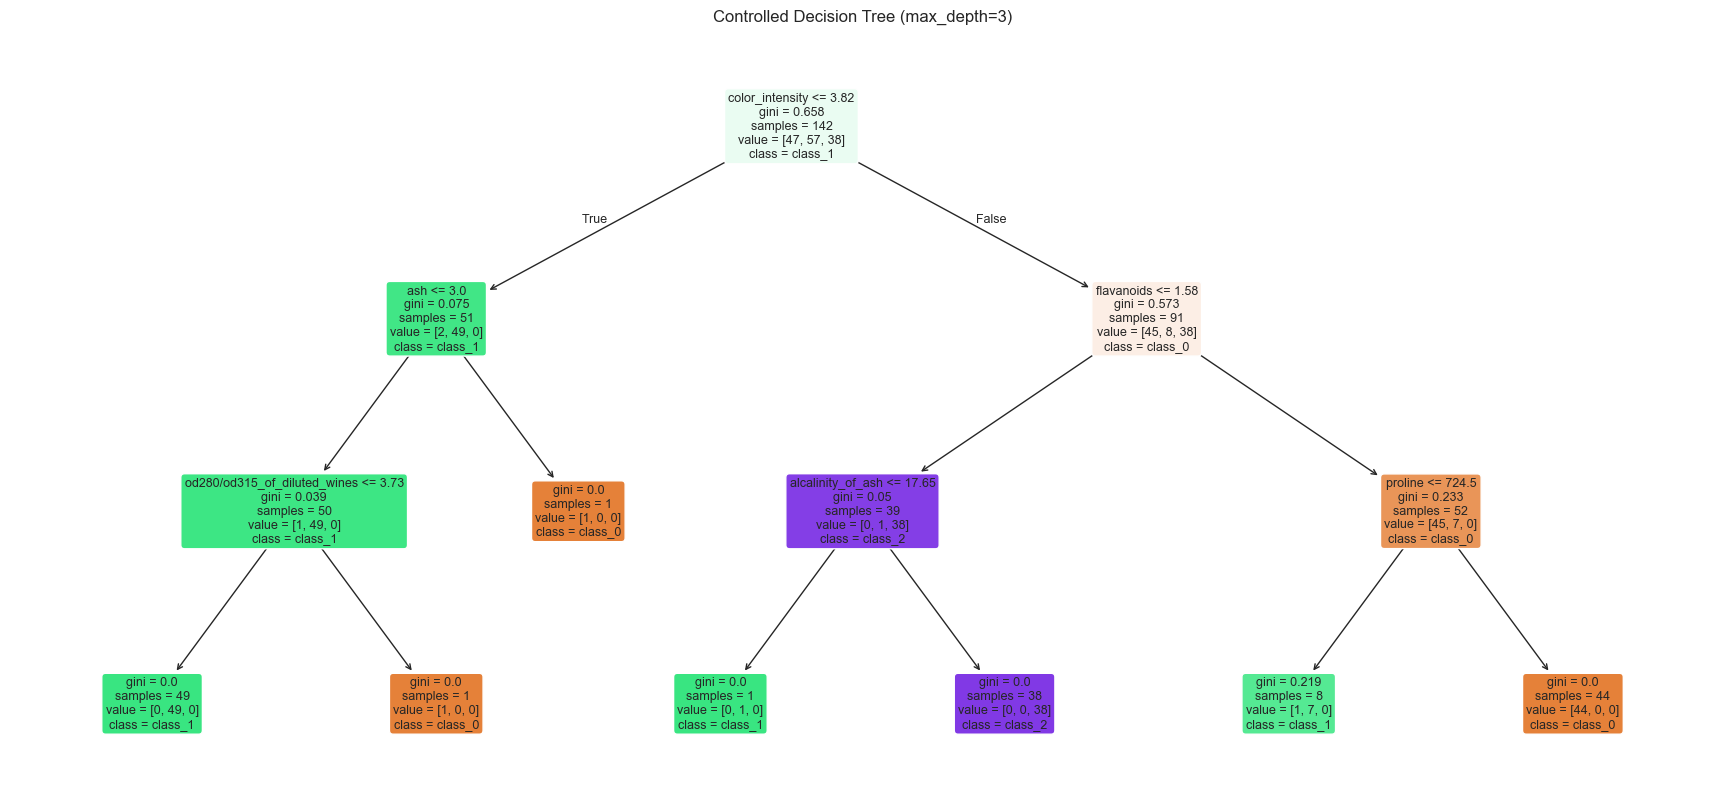

In [12]:
plt.figure(figsize=(22, 10))
plot_tree(
    tree_controlled,
    feature_names=X.columns,
    class_names=list(wine.target_names),
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Controlled Decision Tree (max_depth=3)")
plt.show()


## 8. Tree 구조 시각화 — `Graphviz` (선택)

- Graphviz 패키지와 시스템 `dot` 명령이 준비되어 있으면 더 깔끔한 시각화가 가능합니다.
- 준비되어 있지 않으면 아래 메시지를 확인하고 넘어가면 됩니다.


In [30]:
dot_data = export_graphviz(
    tree_controlled,
    out_file=None,
    feature_names=X.columns,
    class_names=list(wine.target_names),
    filled=True,
    rounded=True,
    special_characters=True,
)

try:
    import graphviz
    graphviz.Source(dot_data)
except Exception as e:
    print("Graphviz 렌더링을 건너뜁니다:", e)
    print("plot_tree 시각화 셀만으로도 실습 진행에는 문제 없습니다.")


## 9. 단일 Tree의 Feature Importance 확인

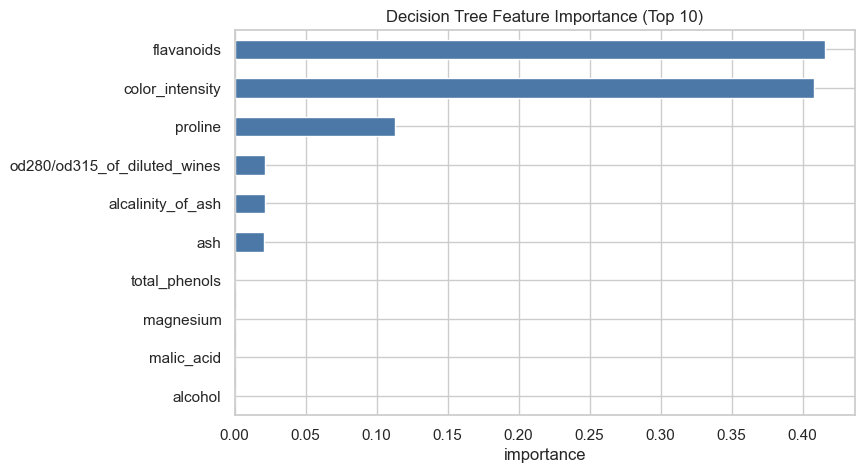

,importance
flavanoids,0.415865
color_intensity,0.407831
proline,0.113104
od280/od315_of_diluted_wines,0.021387
alcalinity_of_ash,0.021264
ash,0.020548
alcohol,0.000000
malic_acid,0.000000
magnesium,0.000000
total_phenols,0.000000


In [14]:
tree_importance = pd.Series(tree_controlled.feature_importances_, index=X.columns)
tree_importance = tree_importance.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
tree_importance.head(10).sort_values().plot(kind="barh", color="#4C78A8")
plt.title("Decision Tree Feature Importance (Top 10)")
plt.xlabel("importance")
plt.show()

tree_importance.head(10).to_frame("importance")


## 10. Random Forest 학습

- 이제 여러 Tree를 모은 **Random Forest**를 학습합니다.
- 핵심은 단일 Tree보다 **train/test gap이 줄고 성능이 안정화되는지** 확인하는 것입니다.


In [32]:
forest = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
forest.fit(X_train, y_train)

result_forest = evaluate_classifier(
    forest, X_train, X_test, y_train, y_test, "RandomForest (300 trees)"
)
pd.DataFrame([result_forest])


,model,train_accuracy,test_accuracy,train_f1_macro,test_f1_macro
0,RandomForest (300 trees),1.0,1.0,1.0,1.0


In [33]:
all_results = pd.DataFrame([
    result_tree_full,
    result_tree_controlled,
    result_forest,
])

all_results.style.format({
    "train_accuracy": "{:.3f}",
    "test_accuracy": "{:.3f}",
    "train_f1_macro": "{:.3f}",
    "test_f1_macro": "{:.3f}",
})


,model,train_accuracy,test_accuracy,train_f1_macro,test_f1_macro
0,DecisionTree (full depth),1.000,0.944,1.000,0.946
1,DecisionTree (max_depth=3),0.993,0.944,0.994,0.946
2,RandomForest (300 trees),1.000,1.000,1.000,1.000


## 11. Random Forest의 Feature Importance

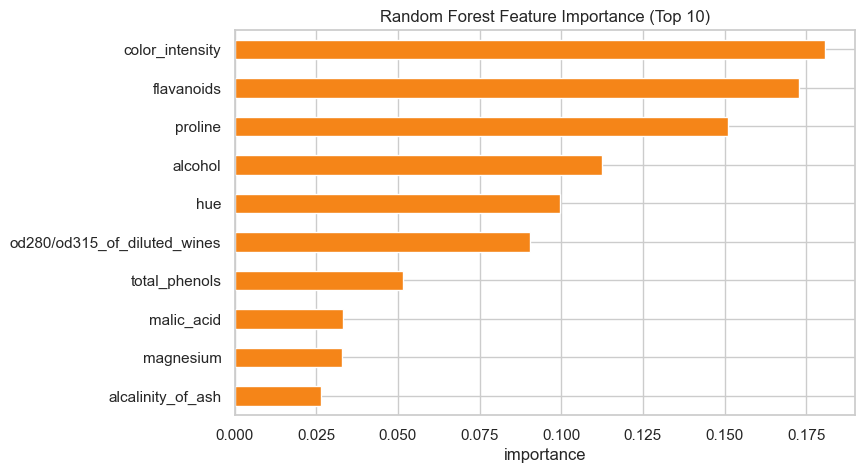

,importance
color_intensity,0.180805
flavanoids,0.172865
proline,0.151067
alcohol,0.112384
hue,0.099592
od280/od315_of_diluted_wines,0.090361
total_phenols,0.051563
malic_acid,0.033140
magnesium,0.032820
alcalinity_of_ash,0.026338


In [34]:
forest_importance = pd.Series(forest.feature_importances_, index=X.columns)
forest_importance = forest_importance.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
forest_importance.head(10).sort_values().plot(kind="barh", color="#F58518")
plt.title("Random Forest Feature Importance (Top 10)")
plt.xlabel("importance")
plt.show()

forest_importance.head(10).to_frame("importance")


## 12. Confusion Matrix와 분류 리포트 확인

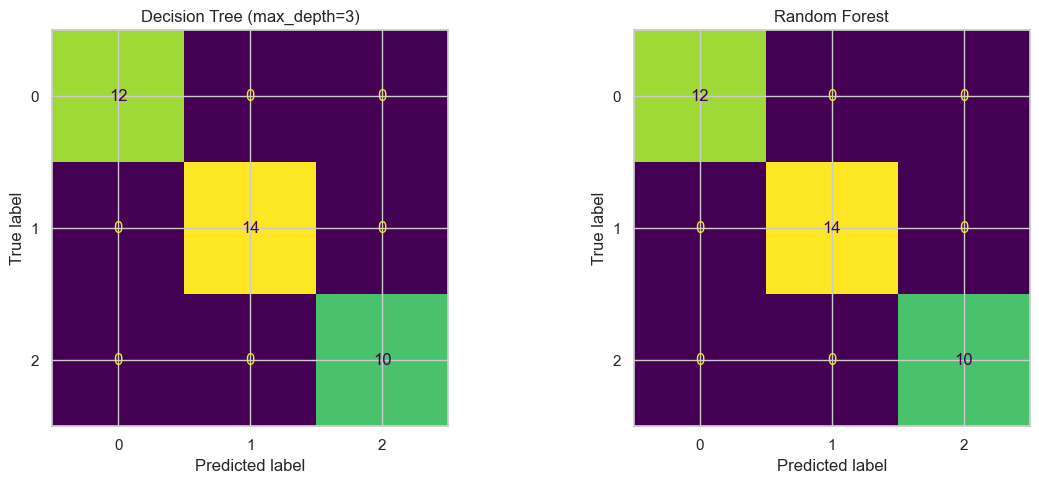

[Decision Tree]
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

[Random Forest]
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    tree_controlled, X_test, y_test, ax=axes[0], colorbar=False
)
axes[0].set_title("Decision Tree (max_depth=3)")

ConfusionMatrixDisplay.from_estimator(
    forest, X_test, y_test, ax=axes[1], colorbar=False
)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

print("[Decision Tree]")
print(classification_report(y_test, tree_controlled.predict(X_test), target_names=wine.target_names))

print("[Random Forest]")
print(classification_report(y_test, forest.predict(X_test), target_names=wine.target_names))


## 13. 실습 해석 가이드

### 확인할 포인트
1. 제한 없는 Tree는 train 성능이 지나치게 높지 않았는가?
2. `max_depth=3`으로 제어했을 때 test 성능이 어떻게 변했는가?
3. Random Forest는 단일 Tree보다 더 안정적인가?
4. 중요도가 높게 나온 변수는 왜 높았을까?
5. 중요도를 곧바로 **인과관계**로 해석하면 왜 위험한가?

### 한 줄 정리
- **Decision Tree**: 해석은 쉽지만 과적합과 불안정성에 주의
- **Random Forest**: 안정적인 baseline에 유리
- **Feature Importance**: 유용하지만 과신 금지


## 14. 다음 주 브릿지

이번 주는 여러 Tree를 **병렬로 모아 안정성을 높이는 Bagging/Random Forest**를 다뤘습니다.  
다음 주는 여기서 한 단계 더 나아가, **이전 모델의 오차를 순차적으로 보완하는 Boosting** 계열로 이동합니다.

즉, 다음 주 핵심 질문은 다음과 같습니다.
- Random Forest가 안정적이라면, 왜 XGBoost/LightGBM이 더 자주 언급될까?
- Bagging과 Boosting은 무엇이 다른가?
